# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib tk
!chcp 65001
!dir

Active code page: 65001
 Volume in drive E has no label.
 Volume Serial Number is 7E48-815E

 Directory of e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\05 Snippets

07.11.2025  22:23    <DIR>          .
22.11.2025  01:23    <DIR>          ..
07.11.2025  22:23           168 919 05 Snippets.ipynb
07.11.2025  22:23    <DIR>          datasets
05.12.2025  18:11    <DIR>          modules
               1 File(s)        168 919 bytes
               4 Dir(s)  332 913 668 096 bytes free


Импорт библиотек и модулей

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

In [3]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

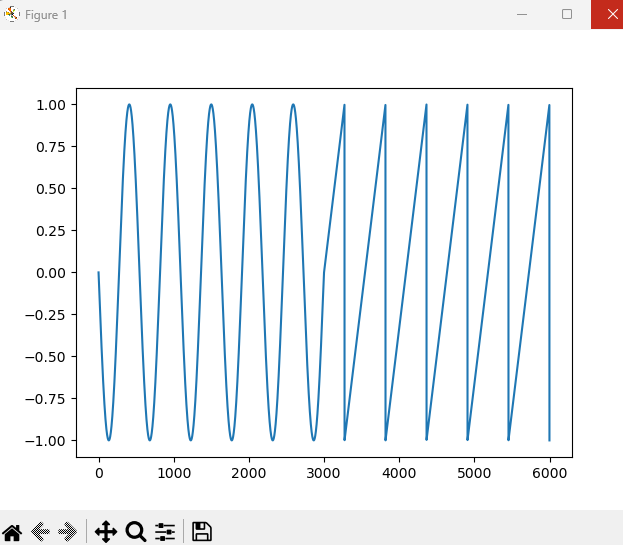

In [4]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

In [5]:
#Визуализация результатов
plot_snippets(ts, snp)

600


<Axes: >

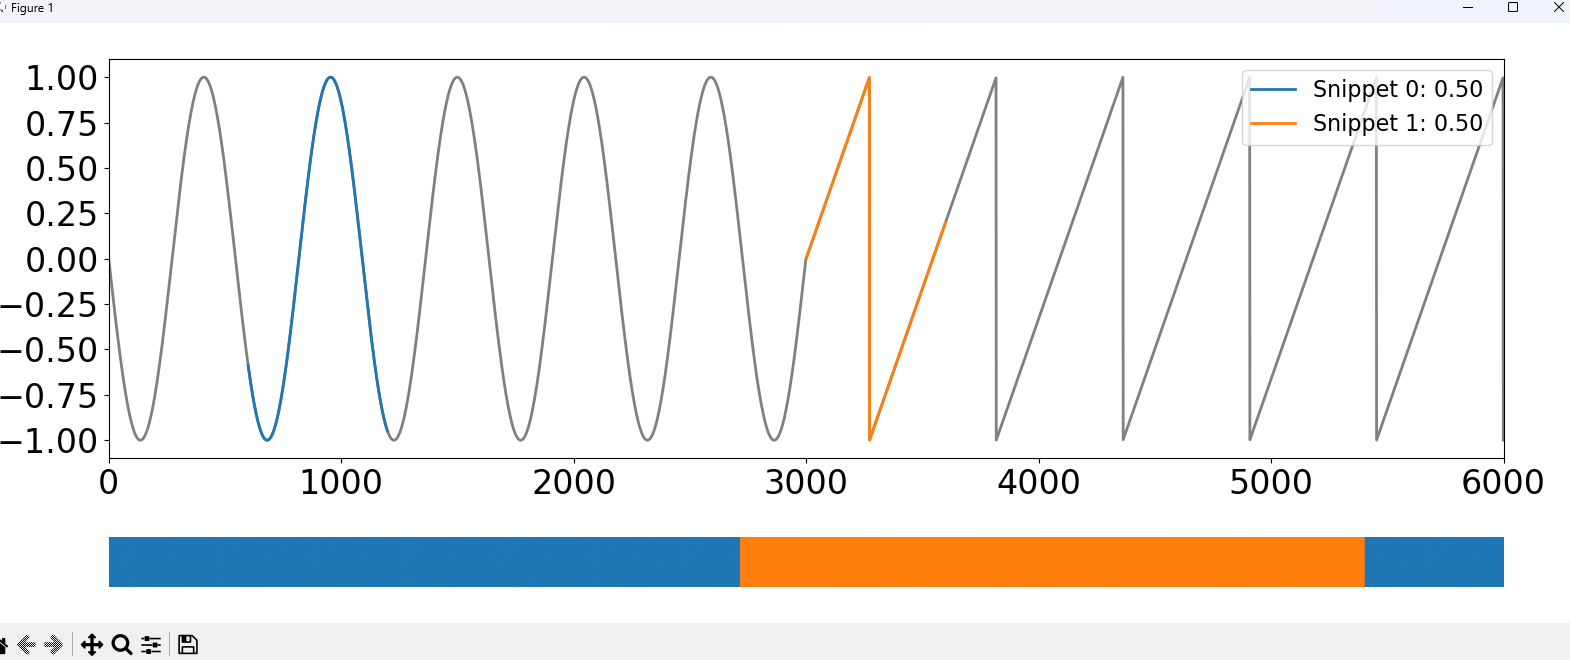

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [6]:
data = np.loadtxt('./datasets/PAMAP/PAMAP.txt')

start_time = 1790
end_time = 1930
timestamp = data[0]
activityID = data[1]
gyrsdata = data[11]

filteredgyrsdata = gyrsdata[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredactivityIDdata = activityID[np.where((timestamp >= start_time) & (timestamp <= end_time))]

filteredactivityIDdata -= filteredactivityIDdata.min()

snp = snippets(filteredgyrsdata, 600, 2, percentage=0.5)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

In [7]:
plot_snippets(filteredgyrsdata, snp)

600


<Axes: >

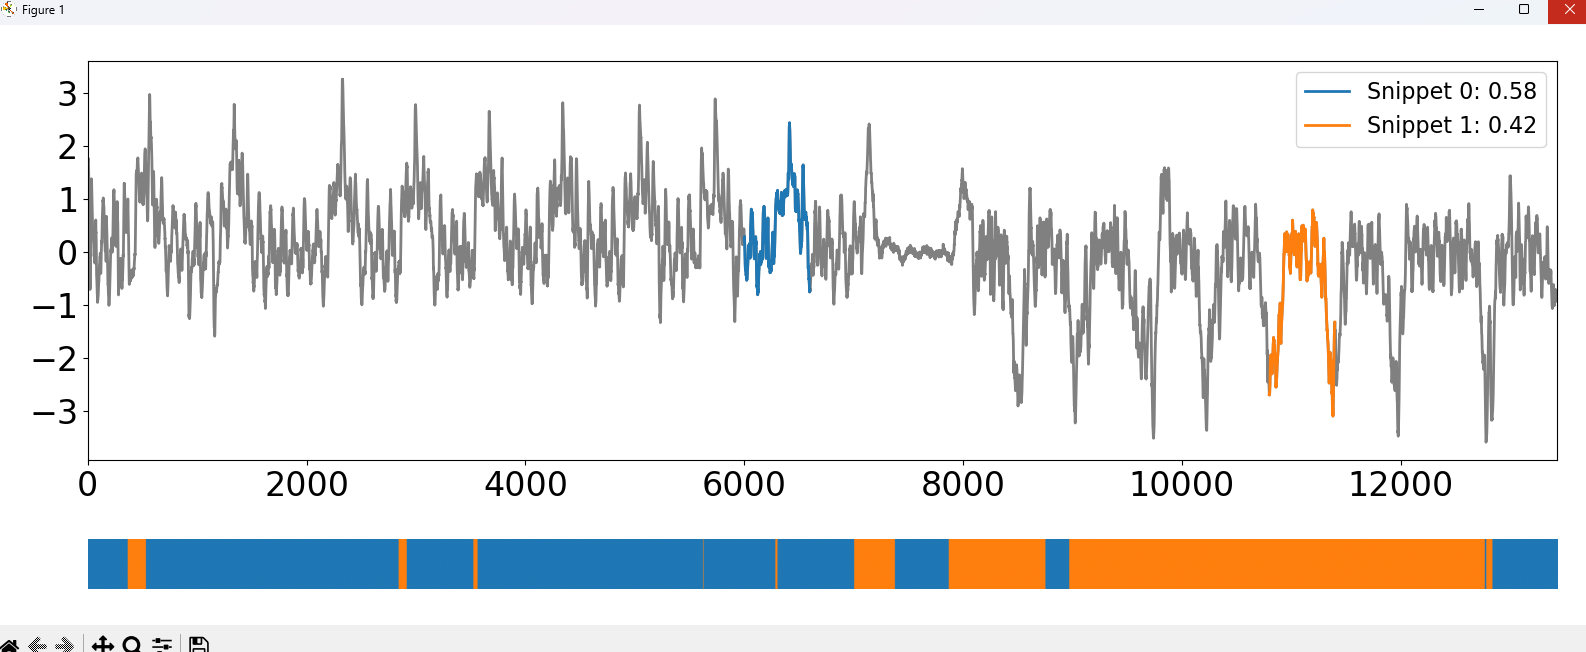

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [8]:
from sklearn.metrics import accuracy_score
import numpy as np
snpfilteredactivityIDdata = np.zeros(len(filteredactivityIDdata))
for value, start, end in snp[-1]:
    snpfilteredactivityIDdata[start:end] = value

accuracy = accuracy_score(filteredactivityIDdata, snpfilteredactivityIDdata)
print(f"Точность классификации: {accuracy:.2f}")

Точность классификации: 0.86


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Как видно из точности, 86% меток активностей, предсказанных на основе сниппетов, совпадают, что весьма хорошо. Сниппеты хорошо представляют типичные паттерны активностей и позволяют кластеризовать временные ряды.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [9]:
data = np.loadtxt('./datasets/PAMAP/PAMAP.txt')

start_time = 1790
end_time = 1930

timestamp = data[0] 
activityID = data[1] 
x = data[10] # X
y = data[11] # Y
z = data[12] # Z

filteredx = x[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredy = y[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredz = z[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredactivityIDdata = activityID[np.where((timestamp >= start_time) & (timestamp <= end_time))]

filteredactivityIDdata -= filteredactivityIDdata.min()
xsnp = snippets(filteredx, 600, 2,percentage=0.5)
plot_snippets(filteredx, snp)

600


<Axes: >

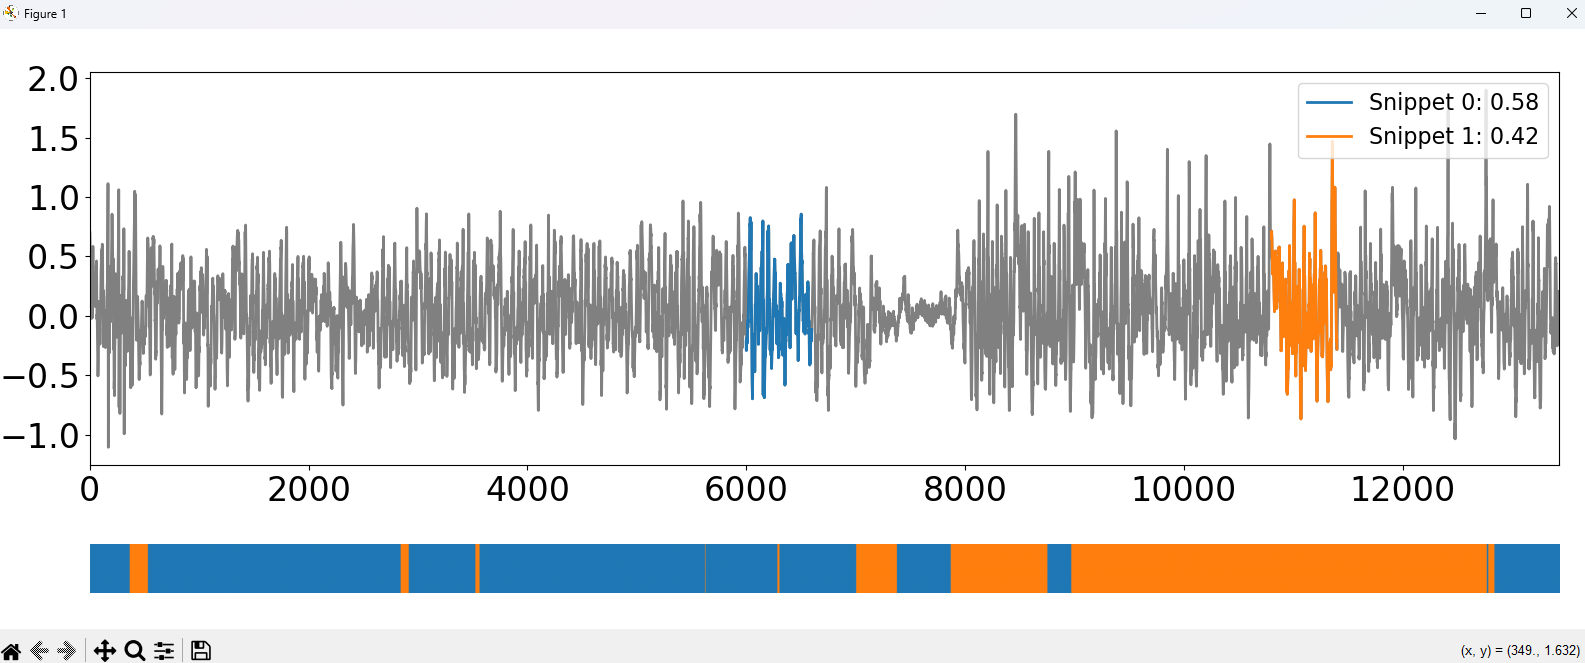

In [10]:
ysnp = snippets(filteredy, 600, 2,percentage=0.5)
plot_snippets(filteredy, snp)

600


<Axes: >

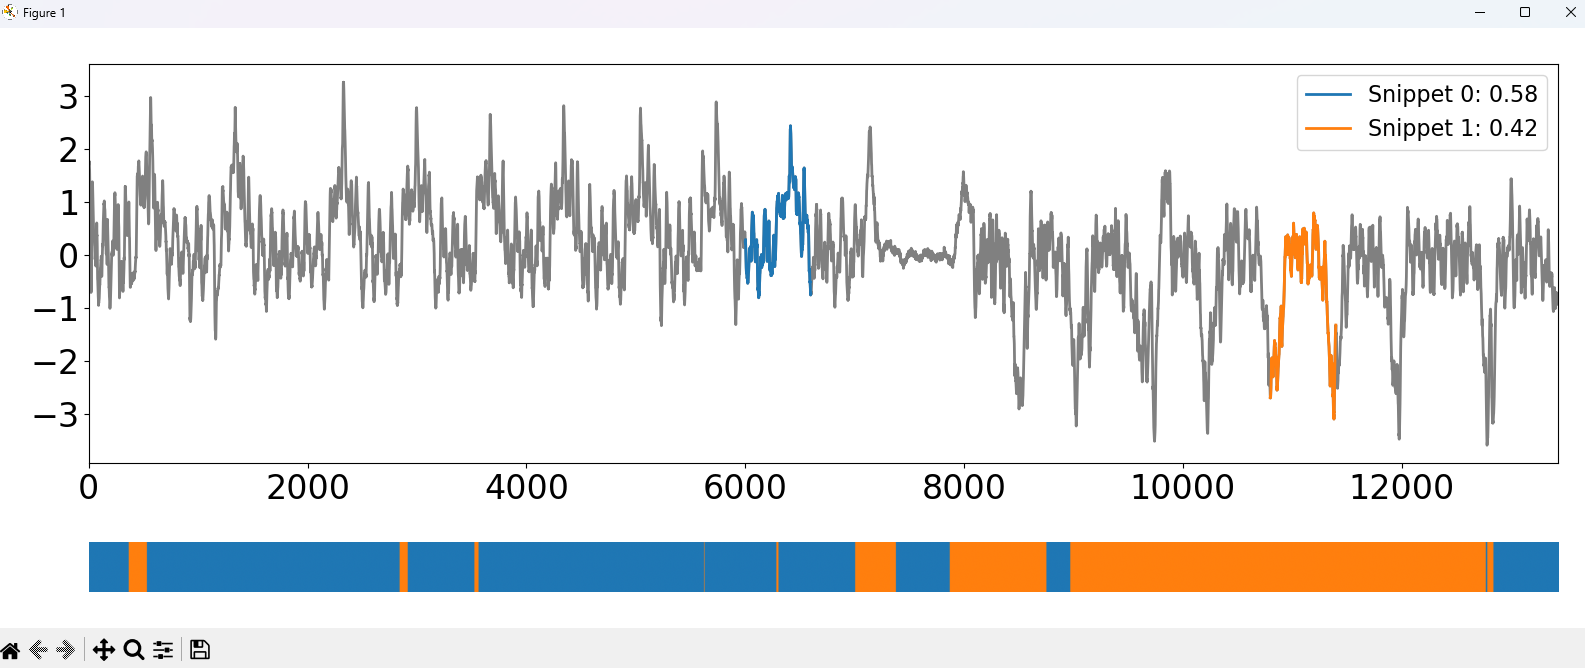

In [11]:
zsnp = snippets(filteredz, 600, 2, percentage=0.5)
plot_snippets(filteredz, snp)

600


<Axes: >

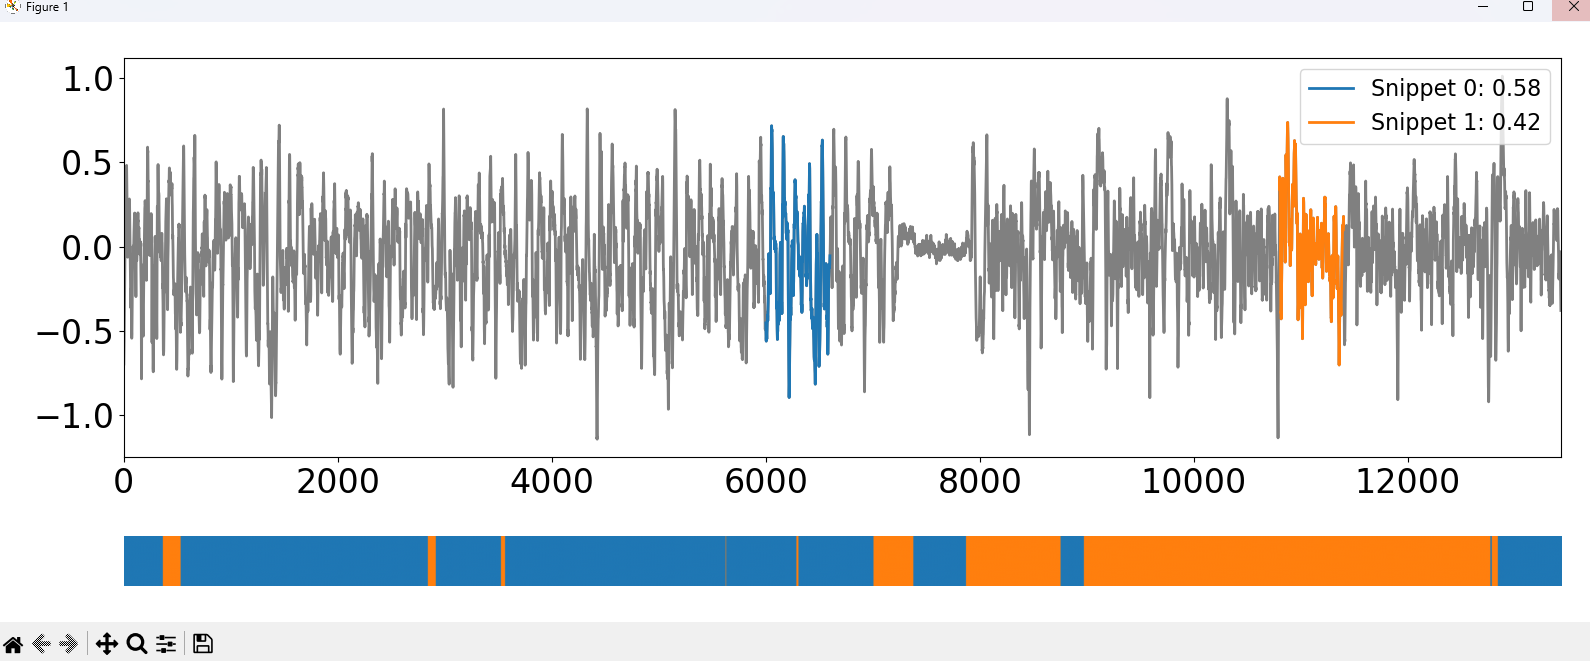

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [12]:
xactivity = np.zeros(len(filteredactivityIDdata))
yactivity = np.zeros(len(filteredactivityIDdata))
zactivity = np.zeros(len(filteredactivityIDdata))

for value, start, end in xsnp[-1]:
    xactivity[start:end] = value

for value, start, end in ysnp[-1]:
    yactivity[start:end] = value

for value, start, end in zsnp[-1]:
    zactivity[start:end] = value

snpactivity = np.zeros(len(filteredactivityIDdata))

for i, votes in enumerate(zip(xactivity, yactivity, zactivity)):
    snpactivity[i] = np.argmax(np.bincount(votes))

accuracy = accuracy_score(filteredactivityIDdata, snpactivity)
print(f"Точность классификации: {accuracy:.2f}")

C:\Users\Check\AppData\Local\Temp\ipykernel_19380\114473560.py:17: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  snpactivity[i] = np.argmax(np.bincount(votes))


Точность классификации: 0.89


❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Использование 3 осей повысило точность алгоритма на 3%, что очень неплохо, учитывая и так неплохую точность.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [13]:
profileareas = []

for K in range(1, 5):
    xsnp, ysnp, zsnp = (snippets(data, 10, K, percentage=0.5)
                           for data in (filteredx, filteredy, filteredz))

    profilearea = np.min([xsnp[-2][k] + ysnp[-2][k] + zsnp[-2][k]
                           for k in range(K)])

    profileareas.append(profilearea)

changes = [profileareas[k - 1] / profileareas[k] - 1 for k in range(1, 4)]

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [17]:
kvalues = np.arange(1, 5) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(kvalues, profileareas, color='skyblue', edgecolor='black')
ax1.set_title('ProfileArea для различных значений k')
ax1.set_xlabel('k')
ax1.set_ylabel('ProfileArea')

ax2.bar(kvalues[1:], changes, color='lightcoral', edgecolor='black')
ax2.set_title('Change_k для различных значений k')
ax2.set_xlabel('k')
ax2.set_ylabel('Change_k')

plt.tight_layout()
plt.show()


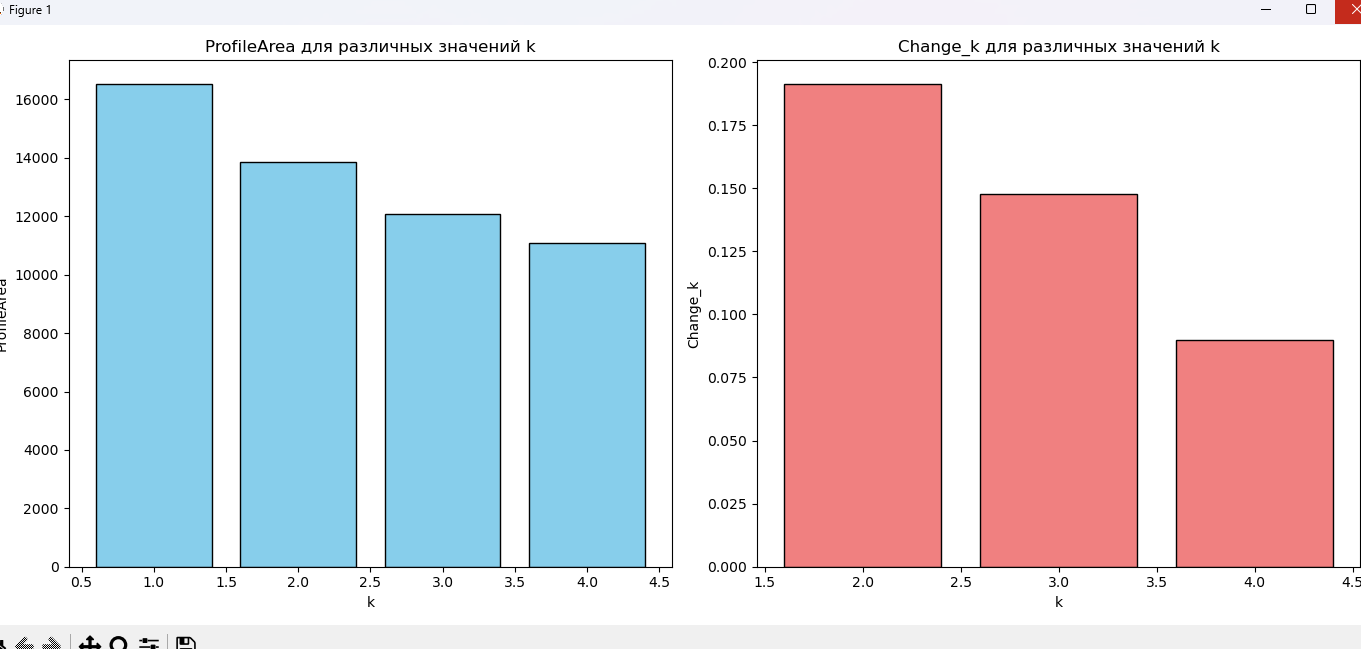

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?

Заметна корелляция между размером сниппета k и характеристиками временного ряда. k2 достаточно неплох и имеет наибольшую разницу, хотя как видно, k3 и k4 еще не достигли точки, при которой дальнейшее увеличение сниппета почти не играет роли (дальнейшие расчеты привели бы к большим временным затратам).  